In [45]:
import sys,os
sys.path.append('../')
os.environ["JAX_PLATFORMS"] = "cpu"
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np 
from corr_coeff_functions import * 
from geometry import (L2_distance,
                      build_get_similarities,
                      normalized_L2_distance,
                      build_information_imbalance,
                      mapped_compute_ranks,
                      )
from utils_shared_features import correlated_gaussian_batch


average_xis = True

# Example
master_seed = 12345
master_key = jax.random.PRNGKey(master_seed)
keyX, keyY = jax.random.split(master_key)
data_key = jax.random.PRNGKey(0)
key_distances = jax.random.PRNGKey(42)
key_distances, subkey_distances = jax.random.split(key_distances)

# jack_seed = 9999
# jack_key = jax.random.PRNGKey(jack_seed)
# ratio_jackknife = 0.5

my_xi_fn = build_corr_coeff_2D_ties(average=average_xis)
rankdata_2D_ties = build_rankdata_2D_ties()
II_fn = build_information_imbalance(k=1)


def compute_metrics_for_alpha(alpha, 
                              data_key, 
                              Ns, 
                              N, 
                              get_similarities, 
                              rankdata_2D_ties,
                              my_xi_fn,
                              II_fn,
                              keyX,
                              keyY):
    """
    Generate data for a given alpha, compute correlations and information imbalance.
    Returns mean_xi, std_xi, inf_imb, inf_imb_std.
    """
    x, y = correlated_gaussian_batch(data_key, Ns, N, alpha)
    sim_X, sim_Y = get_similarities(x, y)

    Rx = rankdata_2D_ties(sim_X, keyX)
    Ry = rankdata_2D_ties(sim_Y, keyY)
    mean_xi, std_xi = my_xi_fn((Rx, Ry))

    R_II = mapped_compute_ranks(method="min")(sim_X, sim_Y)
    inf_imb, inf_imb_std = II_fn(R_II[0], R_II[1])

    return mean_xi, std_xi, inf_imb, inf_imb_std

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# Settings
# -------------------------------------------------------------------------

Ns = 3000 
get_similarities = build_get_similarities(key=subkey_distances, 
                                        sample_size=Ns, 
                                        similarity_fn=L2_distance,
                                        )


N_values = [3,50]  # dynamically handle these

alphas = np.concatenate([np.array([0.01]),
                        np.linspace(0.1, 1.0, 10)])

# Markers and line styles for plotting
markers = ['o', 's', '^', 'D', 'v']
lines = ['-', '--', '-.', ':']

# -------------------------------------------------------------------------
# Compute results with standard deviations
# -------------------------------------------------------------------------
results_inf_xy = {}
results_inf_xy_std = {}
results_inf_yx = {}
results_inf_yx_std = {}
results_xi_xy = {}
results_xi_xy_std = {}
results_xi_yx = {}
results_xi_yx_std = {}

for i, N in enumerate(N_values):
    inf_curve_xy = []
    inf_curve_xy_std = []
    inf_curve_yx = []
    inf_curve_yx_std = []
    xi_curve_xy = []
    xi_curve_xy_std = []
    xi_curve_yx = []
    xi_curve_yx_std = []
    for alpha in alphas:
        mean_xi, std_xi, inf_imb, inf_imb_std = compute_metrics_for_alpha(
            alpha,
            data_key,
            Ns,
            N,
            get_similarities,
            rankdata_2D_ties,
            my_xi_fn,
            II_fn,
            keyX,
            keyY,
        )
        inf_curve_xy.append(1.0 - float(np.array(inf_imb)[0]))
        inf_curve_xy_std.append(float(np.array(inf_imb_std)[0]))
        inf_curve_yx.append(1.0 - float(np.array(inf_imb)[1]))
        inf_curve_yx_std.append(float(np.array(inf_imb_std)[1]))
        xi_curve_xy.append(float(np.array(mean_xi)[0]))
        xi_curve_xy_std.append(float(np.array(std_xi)[0]))
        xi_curve_yx.append(float(np.array(mean_xi)[1]))
        xi_curve_yx_std.append(float(np.array(std_xi)[1]))
    
    results_inf_xy[N] = inf_curve_xy
    results_inf_xy_std[N] = inf_curve_xy_std
    results_inf_yx[N] = inf_curve_yx
    results_inf_yx_std[N] = inf_curve_yx_std
    results_xi_xy[N] = xi_curve_xy
    results_xi_xy_std[N] = xi_curve_xy_std
    results_xi_yx[N] = xi_curve_yx
    results_xi_yx_std[N] = xi_curve_yx_std

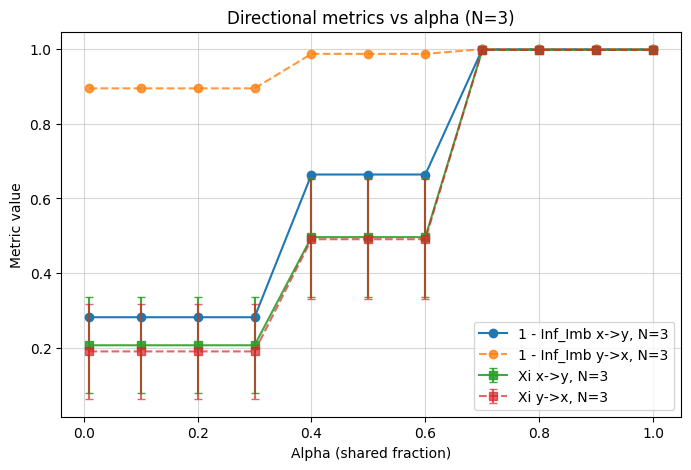

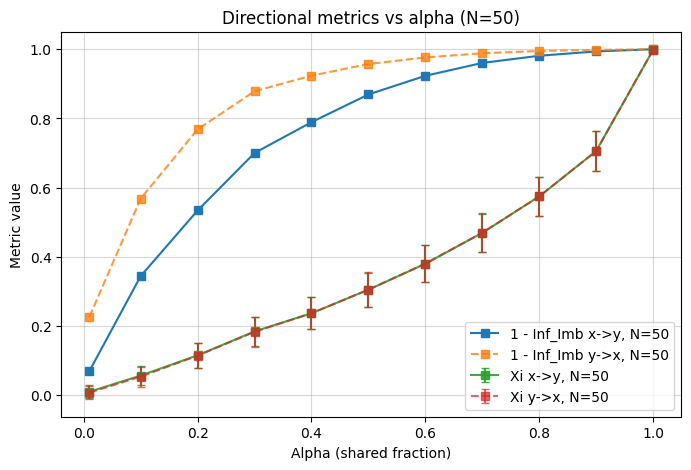

In [47]:
for i, N in enumerate(N_values):
    marker = markers[i % len(markers)]
    
    plt.figure(figsize=(8,5))
    
    # Information Imbalance (directional, no error bars)
    plt.plot(alphas, results_inf_xy[N], marker=marker, linestyle='-',
             label=f'1 - Inf_Imb x->y, N={N}')
    plt.plot(alphas, results_inf_yx[N], marker=marker, linestyle='--',
             label=f'1 - Inf_Imb y->x, N={N}', alpha=0.8)
    
    # Xi (directional)
    plt.errorbar(alphas, results_xi_xy[N], yerr=results_xi_xy_std[N], fmt='s-', capsize=3,
                 label=f'Xi x->y, N={N}', alpha=0.9)
    plt.errorbar(alphas, results_xi_yx[N], yerr=results_xi_yx_std[N], fmt='s--', capsize=3,
                 label=f'Xi y->x, N={N}', alpha=0.7)

    plt.xlabel("Alpha (shared fraction)")
    plt.ylabel("Metric value")
    plt.title(f"Directional metrics vs alpha (N={N})")
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()
